In [15]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Using project root:", PROJECT_ROOT)

import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader
import torchmetrics
import numpy as np
import matplotlib.pyplot as plt

import os
from mask_unet.models import get_segmentation_model, DebrisClassifier
from mask_unet.inference import inference_classifier_segmentation
from mask_unet.torchdataset import SegmentationDataset

Using project root: u:\users\beng\Mask_Unet


In [2]:
def get_transforms():
    return A.Compose([
        A.Resize(384, 512),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.Normalize(mean=(0.5,), std=(0.5,)),
        ToTensorV2()
    ])

In [4]:
image_directory = os.path.join(PROJECT_ROOT, 'debris_data/test')
test_ds = SegmentationDataset(path_name=image_directory, transforms=get_transforms())
test_dataloader = DataLoader(test_ds, batch_size=4, shuffle=True)

In [5]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
model = get_segmentation_model()
model.to(DEVICE)

c:\Users\Crab_workstation\anaconda3\envs\mask_unet\lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Crab_workstation\.cache\huggingface\hub\models--smp-hub--resnet34.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [10]:
checkpoint_path = os.path.join(PROJECT_ROOT, "models/Unet_debris_segmentation.pth")
model.load_state_dict(torch.load(checkpoint_path, map_location=torch.device('cpu')))

C:\Users\Crab_workstation\AppData\Local\Temp\ipykernel_19516\3891525158.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path,

<All keys matched successfully>

In [11]:
pixel_accuracies = []
intersection_over_unions = []
metric_iou = torchmetrics.JaccardIndex(task='binary').to(DEVICE)

In [12]:
with torch.no_grad():
    for inputs, targets in test_dataloader:
        inputs = inputs.to(DEVICE).float()
        targets = targets.to(DEVICE).float()

        outputs = model(inputs)
        predicted = (torch.sigmoid(outputs) > 0.5).float()

        correct = (predicted == targets).sum().item()
        total = torch.numel(targets)
        pixel_accuracies.append(correct / total)

        iou = metric_iou(predicted, targets.int())
        intersection_over_unions.append(iou.item())
pixel_accuracy = np.median(pixel_accuracies) * 100
iou_scores = np.median(intersection_over_unions) * 100
print(f"Median Pixel Accuracy: {np.median(pixel_accuracies) * 100:.2f}%")
print(f"Median IoU: {np.median(intersection_over_unions) * 100:.2f}%")

Median Pixel Accuracy: 98.19%
Median IoU: 97.63%


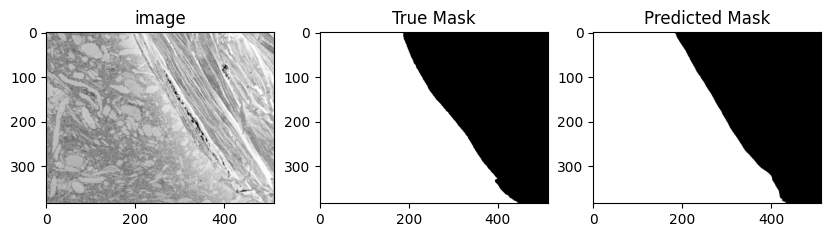

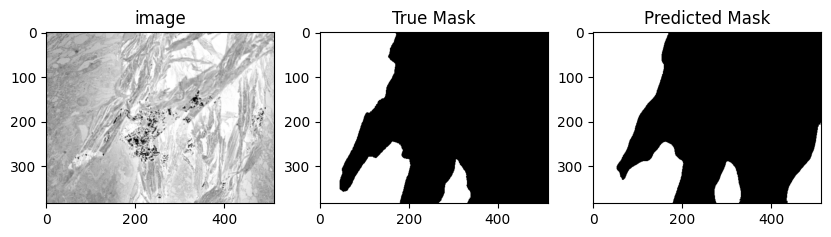

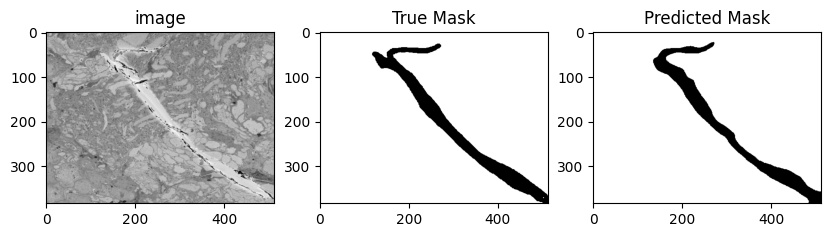

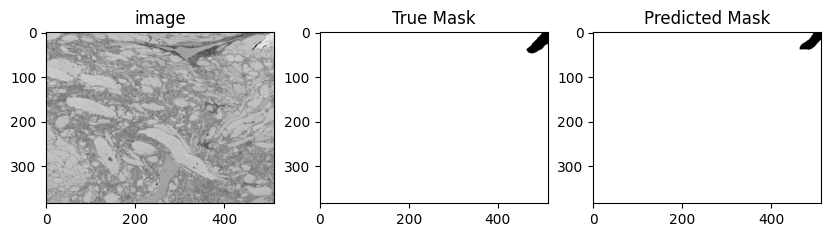

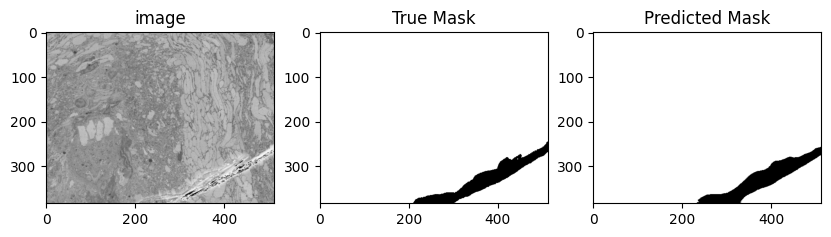

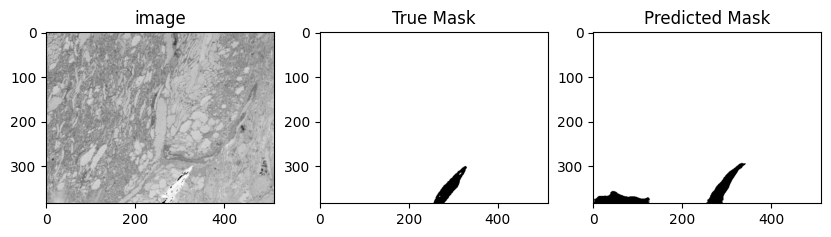

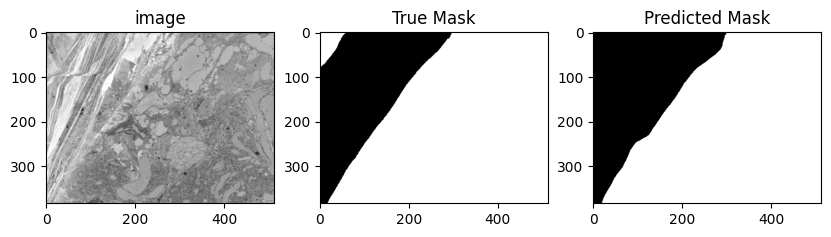

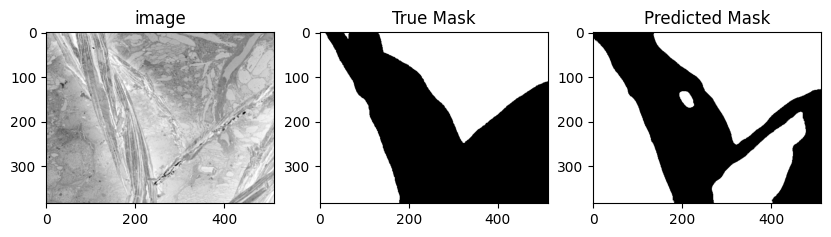

In [16]:
with torch.no_grad():
    for i, (image_test, mask) in enumerate(test_dataloader):
        image_test = image_test.float().to(DEVICE)
        output = model(image_test)
        predicted_mask = (torch.sigmoid(output) > 0.5).float()

        fig, axs = plt.subplots(1, 3, figsize=(10, 10))
        axs[0].imshow(image_test[0][0].cpu(), cmap='gray')
        axs[1].imshow(mask[0][0].cpu(), cmap='gray')
        axs[2].imshow(predicted_mask[0][0].cpu(), cmap='gray')
        axs[0].set_title("image")
        axs[1].set_title("True Mask")
        axs[2].set_title("Predicted Mask")
